In [1]:
# مرحله ۱: نصب پکیج‌ها (حدود ۲-۴ دقیقه طول می‌کشه)
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes xformers datasets



  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-r8pb5tpa/unsloth_2c0c6b89067a457196ea54ef55ae1df7
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-r8pb5tpa/unsloth_2c0c6b89067a457196ea54ef55ae1df7
  Resolved https://github.com/unslothai/unsloth.git to commit f3f9d148874389996636e4fd110c7255b9f62c77
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 152.3 MB/s eta 0:00:00

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
test = "gsm8k_test_translated_all.xlsx"
train = "gsm8k_train_translated_all.xlsx"

# Load the latest version
test_dataset = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arefehrajabian/persian-gsm",
  test,

)

train_dataset = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arefehrajabian/persian-gsm",
  train,

)
train_dataset.head()

/tmp/ipython-input-1223728155.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  test_dataset = kagglehub.load_dataset(


100%|██████████| 298k/298k [00:00<00:00, 326kB/s]
/tmp/ipython-input-1223728155.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train_dataset = kagglehub.load_dataset(


Using Colab cache for faster access to the 'persian-gsm' dataset.


,question,answer,translated_question,steps,translated_steps
0,Natalia sold clips to 48 of her friends in Apr...,72,ناتالیا در ماه آوریل گیره به ۴۸ نفر از دوستانش...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...,ناتالیا در ماه می 48/2 = <<48/2=24>>24 گیره فر...
1,Weng earns $12 an hour for babysitting. Yester...,10,ونگ در ساعت ۱۲ دلار برای نگهداری از کودک دستمز...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...,ونگ 12/60 = $<<12/60=0.2>>0.2 در هر دقیقه درآم...
2,Betty is saving money for a new wallet which c...,5,بتي در حال پس‌انداز پول برای یک کیف پول جدید ا...,"In the beginning, Betty has only 100 / 2 = $<<...",در ابتدا، بتی فقط 100 / 2 = $<<100/2=50>>50 دل...
3,"Julie is reading a 120-page book. Yesterday, s...",42,جولی در حال خواندن کتابی ۱۲۰ صفحه‌ای است. او د...,Maila read 12 x 2 = <<12*2=24>>24 pages today....,میلا امروز 12 x 2 = <<12*2=24>>24 صفحه خواند.\...
4,James writes a 3-page letter to 2 different fr...,624,جیمز هر هفته دو بار نامه‌های ۳ صفحه‌ای به ۲ دو...,He writes each friend 3*2=<<3*2=6>>6 pages a w...,او برای هر دوست ۳*۲=<<3*2=6>> ۶ صفحه در هفته م...


In [3]:
# مرحله ۲: ایمپورت‌ها
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
from transformers import TrainingArguments

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# ۱. تنظیمات اولیه
max_seq_length = 2048
dtype = None
load_in_4bit = True

# ۲. بارگذاری مدل Gemma-3 (نسخه ۴ میلیاردی برای سرعت و دقت بالا در ریاضی عالی است)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-3-4b-it-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# ۳. اضافه کردن LoRA با پارامترهای بهینه شده برای ریاضی
model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # مطابق فایل شما
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 64, # بهبود: افزایش قدرت یادگیری منطق ریاضی
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)


==((====))==  Unsloth 2026.1.2: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


model.safetensors:   0%|          | 0.00/3.23G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


In [11]:
import pandas as pd
from datasets import Dataset
from unsloth import get_chat_template

# ۱. تبدیل مستقیم دیتاست پانداز شما به فرمت مورد نیاز Unsloth
# از آنجایی که از kagglehub استفاده کردید، خروجی شما قطعا DataFrame است
hf_train_dataset = Dataset.from_pandas(train_dataset)

# ۲. تنظیم توکنایزر مخصوص Gemma-3 (تغییر حیاتی برای گوگل)
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma",
)

# ۳. تابع فرمت‌دهی با ستون‌های دقیق دیتاست شما
def formatting_prompts_func(examples):
    questions = examples["translated_question"] # سوال فارسی
    steps     = examples["translated_steps"]    # مراحل حل فارسی (Chain of Thought)
    answers   = examples["answer"]              # جواب نهایی عددی

    texts = []
    for question, step, answer in zip(questions, steps, answers):
        # ساختار پیام منطبق با استاندارد Gemma-3 برای استدلال ریاضی
        messages = [
            {
                "role": "user",
                "content": f"شما یک متخصص ریاضی هستید. سوال زیر را گام‌به‌گام حل کنید:\n\n{question}"
            },
            {
                "role": "assistant",
                "content": f"حل مرحله به مرحله:\n{step}\n\nپاسخ نهایی: {answer}"
            },
        ]
        # تولید متن نهایی برای آموزش
        text = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = False)
        texts.append(text)

    return { "text" : texts }

# ۴. اجرای عملیات مپینگ و پاکسازی ستون‌های اضافی
dataset = hf_train_dataset.map(
    formatting_prompts_func,
    batched = True,
    remove_columns = hf_train_dataset.column_names # حذف ستون‌های xlsx برای جلوگیری از خطای حافظه
)

print(f"✅ تعداد {len(dataset)} نمونه آماده آموزش شدند.")
print("نمونه متن تولید شده برای مدل:")
print(dataset[0]["text"])

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

✅ تعداد 7473 نمونه آماده آموزش شدند.
نمونه متن تولید شده برای مدل:
<bos><start_of_turn>user
شما یک متخصص ریاضی هستید. سوال زیر را گام‌به‌گام حل کنید:

ناتالیا در ماه آوریل گیره به ۴۸ نفر از دوستانش فروخت و سپس در ماه می نصف این تعداد گیره فروخت. در مجموع ناتالیا در ماه آوریل و می چند گیره فروخت؟<end_of_turn>
<start_of_turn>model
حل مرحله به مرحله:
ناتالیا در ماه می 48/2 = <<48/2=24>>24 گیره فروخت.
ناتالیا در مجموع در ماه آوریل و می 48+24 = <<48+24=72>>72 گیره فروخت.
#### 72

پاسخ نهایی: 72<end_of_turn>



In [16]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
import os

# ۱. غیرفعال کردن سرویس‌های اضافه برای جلوگیری از خطا
os.environ["WANDB_DISABLED"] = "true"

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        max_steps = 120,
        learning_rate = 1e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        # اضافه کردن این دو خط برای حل مشکل شما:
        report_to = "none", # جلوگیری از خطای wandb
        logging_dir = "logs", # ذخیره لاگ‌ها به صورت محلی
    ),
)



Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/7473 [00:00<?, ? examples/s]

In [17]:
import os
os.environ["WANDB_DISABLED"] = "true"
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,473 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 65,576,960 of 4,365,656,432 (1.50% trained)


Step,Training Loss
1,2.251900
2,2.357400
3,2.621200
4,2.482000
5,2.236900
6,2.004500
7,1.914400
8,1.680000
9,1.777500
10,1.674300


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


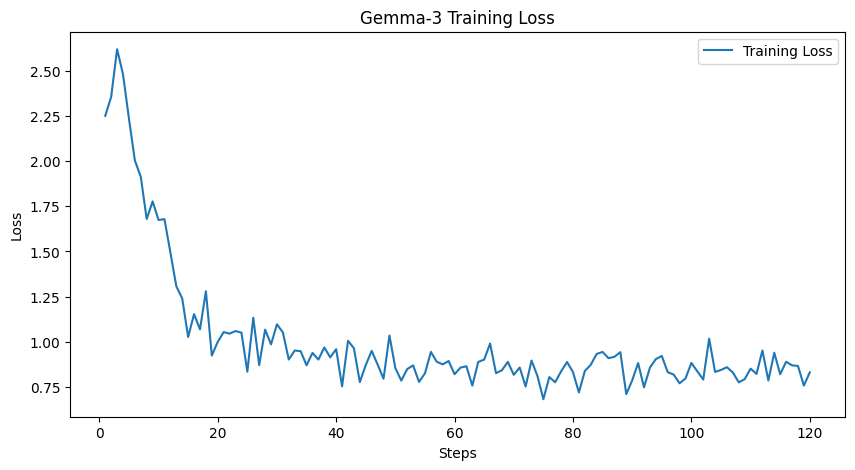

In [18]:
import matplotlib.pyplot as plt

# دریافت آمارهای آموزش از متغیر trainer_stats که قبلا تعریف کردید
history = trainer_stats.metrics
# یا اگر از متغیر trainer استفاده می‌کنید:
# history = trainer.state.log_history

steps = [x['step'] for x in trainer.state.log_history if 'loss' in x]
loss = [x['loss'] for x in trainer.state.log_history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss, label='Training Loss')
plt.title('Gemma-3 Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
# ۱. ذخیره با اسم دلخواه
custom_name = "gemma-3-4b-it-gsm8k-persian"

model.save_pretrained(custom_name)
tokenizer.save_pretrained(custom_name)

# ۲. زیپ کردن همان پوشه برای دانلود
import shutil
shutil.make_archive(custom_name, 'zip', custom_name)

# ۳. دانلود
from google.colab import files
files.download(f"{custom_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# این کد مدل اصلی را با تغییرات شما ترکیب کرده و در یک پوشه جدید ذخیره می‌کند
model.save_pretrained_merged(
    "gemma_math_final_merged", # نام پوشه نهایی
    tokenizer,
    save_method = "merged_16bit", # روش ادغام (دقت بالا)
)

# زیپ کردن برای دانلود (حجم این فایل چند گیگابایت خواهد بود)
import shutil
shutil.make_archive("gemma_math_final_merged", 'zip', "gemma_math_final_merged")

In [ ]:
# ذخیره آداپتورها و توکنایزر به صورت محلی
model.save_pretrained("persian_gemma_lora_model")
tokenizer.save_pretrained("persian_gemma_lora_model")

# آپلود مستقیم آداپتورها به Hugging Face
# model.push_to_hub("your_username/persian_gemma_lora", token = "hf_token")

In [ ]:
# ادغام با مدل اصلی و ذخیره به صورت Float16
model.save_pretrained_merged("persian_gemma_merged_16bit", tokenizer, save_method = "merged_16bit")

# اگر می‌خواهید مستقیم در Hugging Face آپلود شود:
# model.push_to_hub_merged("your_username/persian_gemma_full", tokenizer, save_method = "merged_16bit", token = "hf_token")